In [6]:
import pandas as pd

# Load data
df = pd.read_csv("C:/Users/SOMYA/Downloads/archive (2)/netflix_titles.csv")

# Quick check
print(df.shape)
print(df.columns)
print(df.isnull().sum())

# Convert 'date_added' to datetime after stripping spaces
df['date_added'] = pd.to_datetime(df['date_added'].str.strip(), errors='coerce')

# Fill missing values
df['director'] = df['director'].fillna('Not Available')
df['cast'] = df['cast'].fillna('Not Available')
df['country'] = df['country'].fillna('Not Specified')
df['rating'] = df['rating'].fillna('Not Rated')

# Extract year from date_added
df['year_added'] = df['date_added'].dt.year

# Separate duration numeric and unit
df[['duration_value', 'duration_unit']] = df['duration'].str.extract(r'(\d+)\s*(\D+)')
df['duration_value'] = pd.to_numeric(df['duration_value'], errors='coerce')

# Lowercase genres and strip whitespace
df['listed_in'] = df['listed_in'].str.lower().str.strip()

# Drop duplicates
df.drop_duplicates(inplace=True)

# Save cleaned data
df.to_csv("C:/Users/SOMYA/Downloads/cleaned_netflix_data.csv", index=False)

(8807, 12)
Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')
show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64


In [8]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Set Seaborn style
sns.set(style="whitegrid")

# Load the cleaned Netflix data
df = pd.read_csv("C:/Users/SOMYA/Downloads/cleaned_netflix_data.csv")

# Basic info
print(df.shape)
df.head()


(8807, 15)


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,duration_value,duration_unit
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Not Available,United States,2021-09-25,2020,PG-13,90 min,documentaries,"As her father nears the end of his life, filmm...",2021.0,90.0,min
1,s2,TV Show,Blood & Water,Not Available,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"international tv shows, tv dramas, tv mysteries","After crossing paths at a party, a Cape Town t...",2021.0,2.0,Seasons
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Not Specified,2021-09-24,2021,TV-MA,1 Season,"crime tv shows, international tv shows, tv act...",To protect his family from a powerful drug lor...,2021.0,1.0,Season
3,s4,TV Show,Jailbirds New Orleans,Not Available,Not Available,Not Specified,2021-09-24,2021,TV-MA,1 Season,"docuseries, reality tv","Feuds, flirtations and toilet talk go down amo...",2021.0,1.0,Season
4,s5,TV Show,Kota Factory,Not Available,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"international tv shows, romantic tv shows, tv ...",In a city of coaching centers known to train I...,2021.0,2.0,Seasons


C:\Users\SOMYA\AppData\Local\Temp\ipykernel_12248\2217656912.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=type_counts.index, y=type_counts.values, palette="pastel")


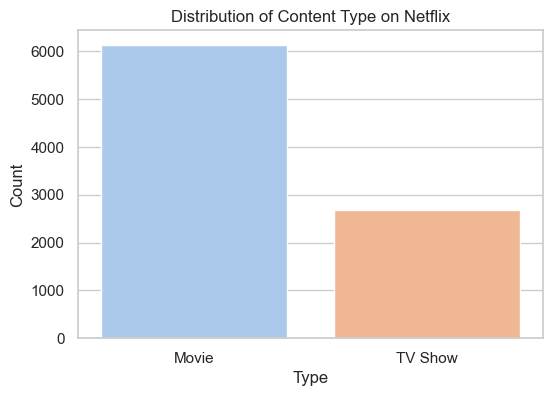

In [9]:
# Count of Movies vs TV Shows
type_counts = df['type'].value_counts()

# Bar plot
plt.figure(figsize=(6,4))
sns.barplot(x=type_counts.index, y=type_counts.values, palette="pastel")
plt.title("Distribution of Content Type on Netflix")
plt.xlabel("Type")
plt.ylabel("Count")
plt.show()

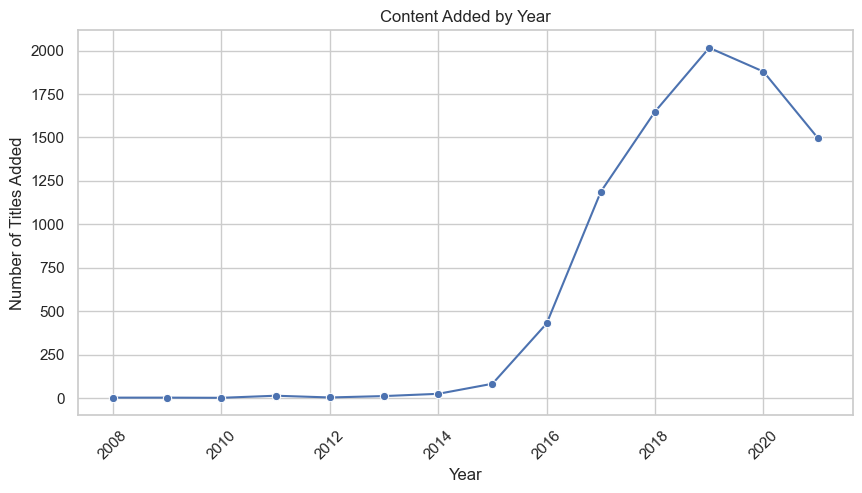

In [10]:
# Content added by year
yearly_counts = df['year_added'].value_counts().sort_index()

plt.figure(figsize=(10,5))
sns.lineplot(x=yearly_counts.index, y=yearly_counts.values, marker='o')
plt.title("Content Added by Year")
plt.xlabel("Year")
plt.ylabel("Number of Titles Added")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

C:\Users\SOMYA\AppData\Local\Temp\ipykernel_12248\192960476.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_countries.index, x=top_countries.values, palette="coolwarm")


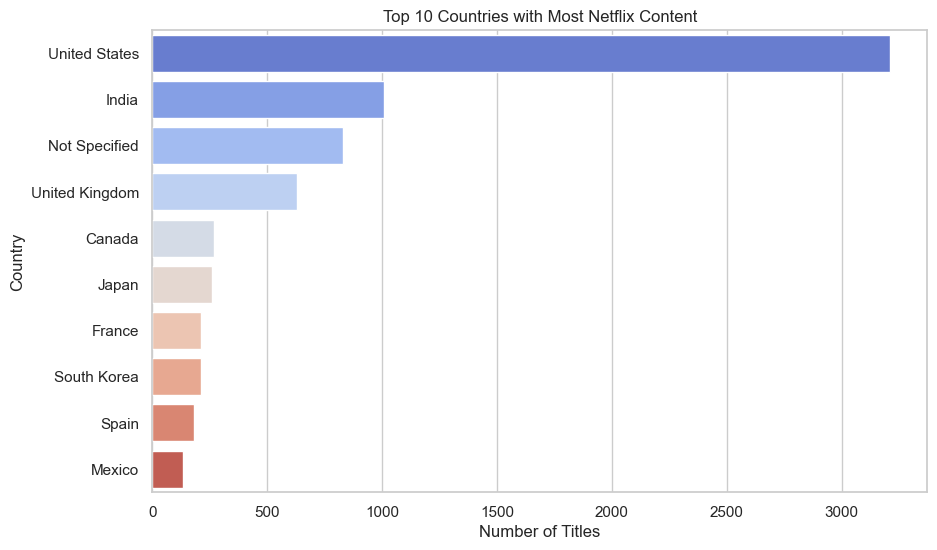

In [11]:
# Clean multiple countries (just use the first one per entry for now)
df['main_country'] = df['country'].str.split(',').str[0]

top_countries = df['main_country'].value_counts().head(10)

plt.figure(figsize=(10,6))
sns.barplot(y=top_countries.index, x=top_countries.values, palette="coolwarm")
plt.title("Top 10 Countries with Most Netflix Content")
plt.xlabel("Number of Titles")
plt.ylabel("Country")
plt.show()


C:\Users\SOMYA\AppData\Local\Temp\ipykernel_12248\3827223501.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Count', y='Genre', data=genre_df, palette='Set2')


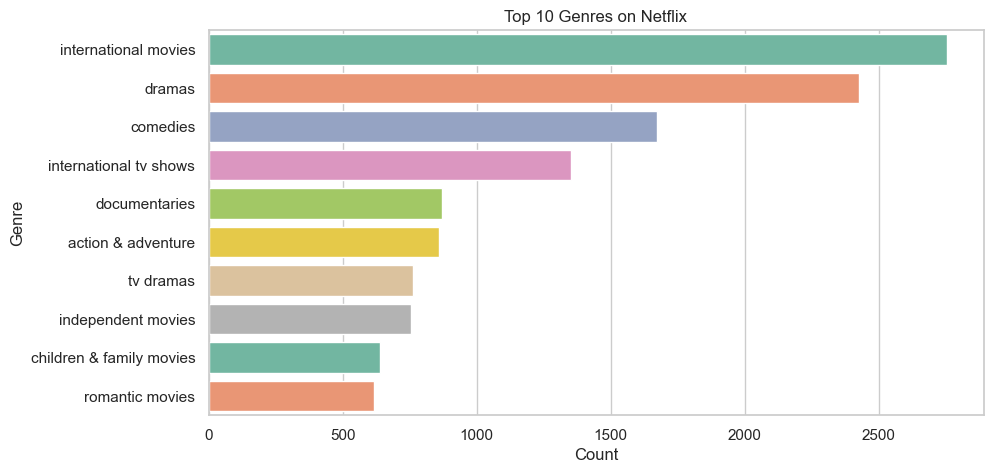

In [12]:
from collections import Counter

# Split and flatten all genres
genres = df['listed_in'].str.split(', ')
flat_genres = [genre for sublist in genres.dropna() for genre in sublist]

genre_counts = Counter(flat_genres)
genre_df = pd.DataFrame(genre_counts.most_common(10), columns=['Genre', 'Count'])

plt.figure(figsize=(10,5))
sns.barplot(x='Count', y='Genre', data=genre_df, palette='Set2')
plt.title("Top 10 Genres on Netflix")
plt.xlabel("Count")
plt.ylabel("Genre")
plt.show()


C:\Users\SOMYA\AppData\Local\Temp\ipykernel_12248\1327095879.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_directors.values, y=top_directors.index, palette='muted')


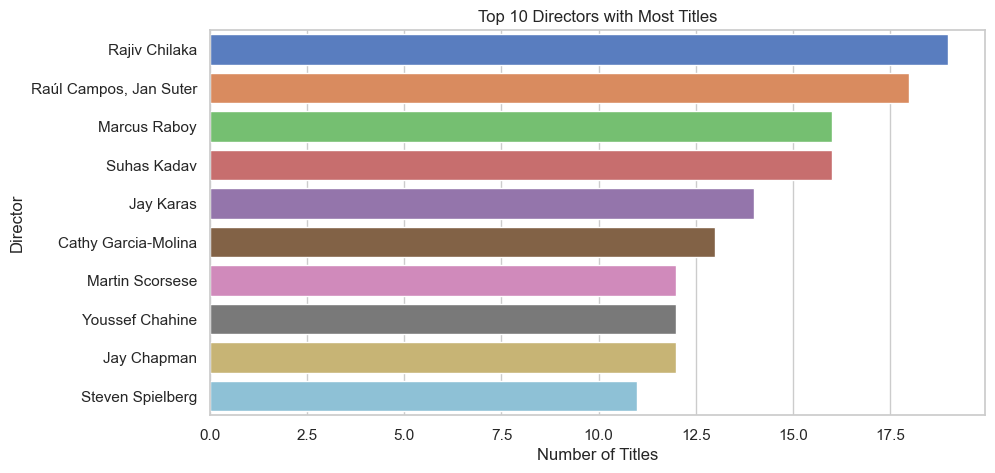

In [13]:
top_directors = df[df['director'] != 'Not Available']['director'].value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_directors.values, y=top_directors.index, palette='muted')
plt.title("Top 10 Directors with Most Titles")
plt.xlabel("Number of Titles")
plt.ylabel("Director")
plt.show()

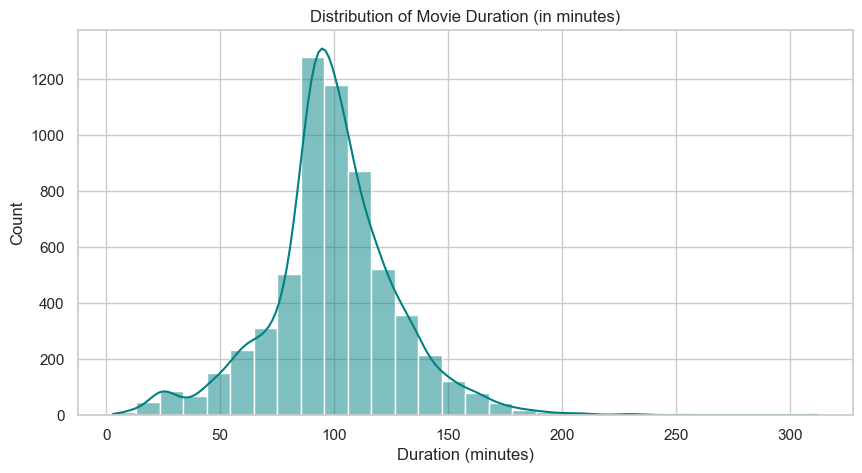

In [14]:
# Movie duration histogram
movie_df = df[df['type'] == 'Movie']

plt.figure(figsize=(10,5))
sns.histplot(movie_df['duration_value'].dropna(), bins=30, kde=True, color='teal')
plt.title("Distribution of Movie Duration (in minutes)")
plt.xlabel("Duration (minutes)")
plt.ylabel("Count")
plt.show()

In [15]:
df.to_csv("C:/Users/SOMYA/Downloads/cleaned_netflix_data.csv", index=False)